Dataset acquired from: https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

# Exploratory Data Analysis and Classification

## Dataset Overview

This project uses the Adult Income dataset, which contains demographic,
employment, and financial information about individuals.

The objective is to build a binary classification model that predicts
whether an individual's annual income exceeds $50,000.

The target variable is `income`, with two classes:
- `<=50K`: Income at or below $50,000
- `>50K`: Income above $50,000

The EDA examines the dataset's structure, data quality, feature
distributions, relationships with income, and potential preprocessing
requirements before model development.

In [198]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [199]:
from sklearn.preprocessing import OrdinalEncoder
import category_encoders as ce

In [200]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler

In [201]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [202]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import optuna

In [203]:
from sklearn.metrics import f1_score,confusion_matrix

In [204]:
import os
import joblib

## 1. Initial Data Inspection and Data Quality

The dataset contains 48,842 observations and 15 columns, including
numerical and categorical features.

The initial inspection checks data types, missing values, and the
distribution of categorical variables.

In this dataset, missing categorical values are represented by `?`
rather than standard null values. These values must be identified and
handled before encoding and model training.

In [205]:
df = pd.read_csv("dataset/adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [206]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [ ]:
print("Null values:")
print(df.isnull().sum())
print("\nMissing values represented by '?':")
print((df == "?").sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDataset shape:", df.shape)

Null values:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

Missing values represented by '?':
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Duplicate rows: 52

Dataset shape: (48842, 15)


## 2. Workclass and Education Analysis

Workclass and education describe an individual's employment category
and educational attainment.

The frequency distributions show how observations are distributed
across categories, while the income-based plots allow us to examine
how income classes vary across these features.

Education is also examined in more detail to determine whether its
categories can be grouped into meaningful ordered levels for
ordinal encoding.

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


<Axes: xlabel='workclass', ylabel='count'>

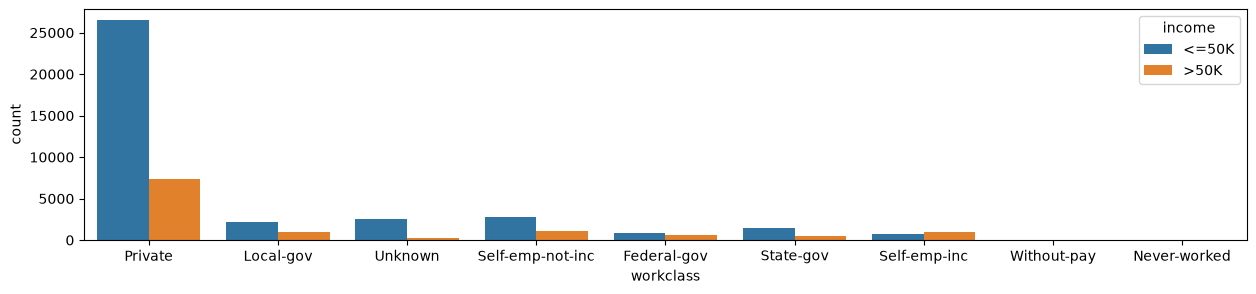

In [208]:
print(df["workclass"].value_counts())
t_df = df[["workclass"]]
t_df.loc[df["workclass"]=="?"] = "Unknown"
df["workclass"] = t_df["workclass"]
plt.figure(figsize=(15,3))
sns.countplot(data=df,x="workclass",hue="income")

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


<Axes: xlabel='education', ylabel='count'>

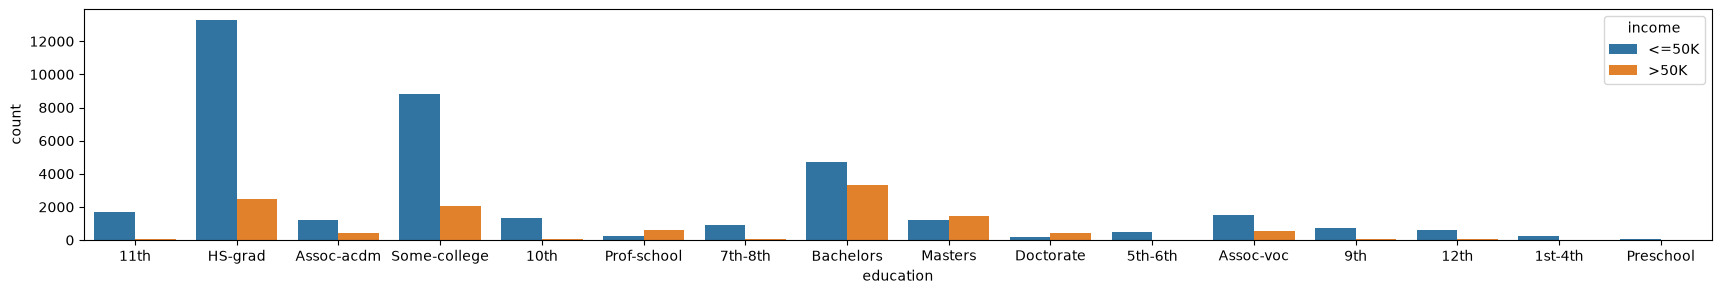

In [210]:
print(df["education"].value_counts())
plt.figure(figsize=(21,3))
sns.countplot(data=df,x="education",hue="income")

In [211]:
edu = df["education"].unique().tolist()
for x in edu:
    count = df["education"].eq(x).sum()
    d50 = len(df.loc[(df["education"].str.strip()==x) & (df["income"].str.strip()=="<=50K")])
    u50 = len(df.loc[(df["education"].str.strip()==x) & (df["income"].str.strip()==">50K")])
    print(f"{x}: Total: {count} | >50k%: {(u50/count)*100} | <=50k% {(d50/count)*100}")

11th: Total: 1812 | >50k%: 5.077262693156733 | <=50k% 94.92273730684326
HS-grad: Total: 15784 | >50k%: 15.857830714647744 | <=50k% 84.14216928535225
Assoc-acdm: Total: 1601 | >50k%: 25.79637726420987 | <=50k% 74.20362273579013
Some-college: Total: 10878 | >50k%: 18.964883250597538 | <=50k% 81.03511674940246
10th: Total: 1389 | >50k%: 6.263498920086392 | <=50k% 93.73650107991361
Prof-school: Total: 834 | >50k%: 73.98081534772182 | <=50k% 26.019184652278177
7th-8th: Total: 955 | >50k%: 6.492146596858639 | <=50k% 93.50785340314135
Bachelors: Total: 8025 | >50k%: 41.283489096573206 | <=50k% 58.71651090342679
Masters: Total: 2657 | >50k%: 54.91155438464433 | <=50k% 45.08844561535567
Doctorate: Total: 594 | >50k%: 72.55892255892256 | <=50k% 27.441077441077443
5th-6th: Total: 509 | >50k%: 5.304518664047151 | <=50k% 94.69548133595285
Assoc-voc: Total: 2061 | >50k%: 25.327510917030565 | <=50k% 74.67248908296943
9th: Total: 756 | >50k%: 5.423280423280423 | <=50k% 94.57671957671958
12th: Total: 6

In [212]:
dct = {"Preschool":"Below-HS", "1st-4th":"Below-HS","5th-6th":"Below-HS","7th-8th":"Below-HS","9th":"Below-HS","10th":"Below-HS","11th":"Below-HS","12th":"Below-HS","Assoc-acdm":"Associate","Assoc-voc":"Associate","Prof-school":"Advanced Degree","Doctorate":"Advanced Degree","HS-grad":"HS-grad","Some-college":"Some-college","Bachelors":"Bachelors","Masters":"Masters"}
df["education"] = df["education"].replace(dct)
df["education"].value_counts()

education
HS-grad            15784
Some-college       10878
Bachelors           8025
Below-HS            6408
Associate           3662
Masters             2657
Advanced Degree     1428
Name: count, dtype: int64

<Axes: xlabel='education', ylabel='count'>

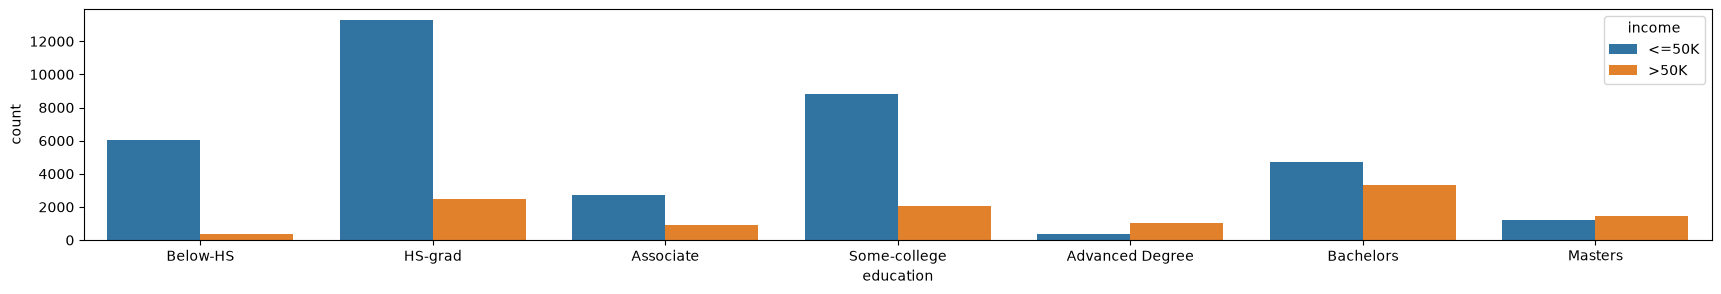

In [213]:
plt.figure(figsize=(21,3))
sns.countplot(data=df,x="education",hue="income")

## 3. Marital Status, Occupation, and Relationship Analysis

This section examines three categorical features related to an
individual's social and employment circumstances.

The count plots compare the distribution of income classes across
marital status, occupation, and relationship categories.

These visualizations help identify differences in the observed
income distribution across categories and highlight rare or
imbalanced groups that may require careful encoding.

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64


<Axes: xlabel='marital-status', ylabel='count'>

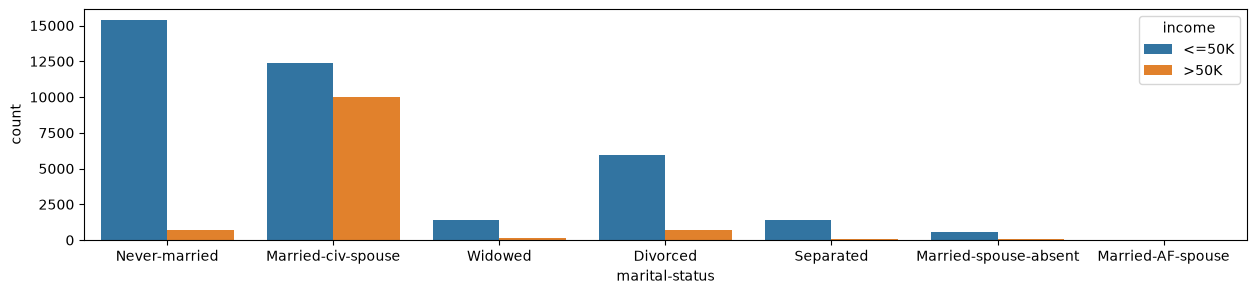

In [215]:
print(df["marital-status"].value_counts())
plt.figure(figsize=(15,3))
sns.countplot(data=df,x="marital-status",hue="income")

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
?                    2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='occupation'>

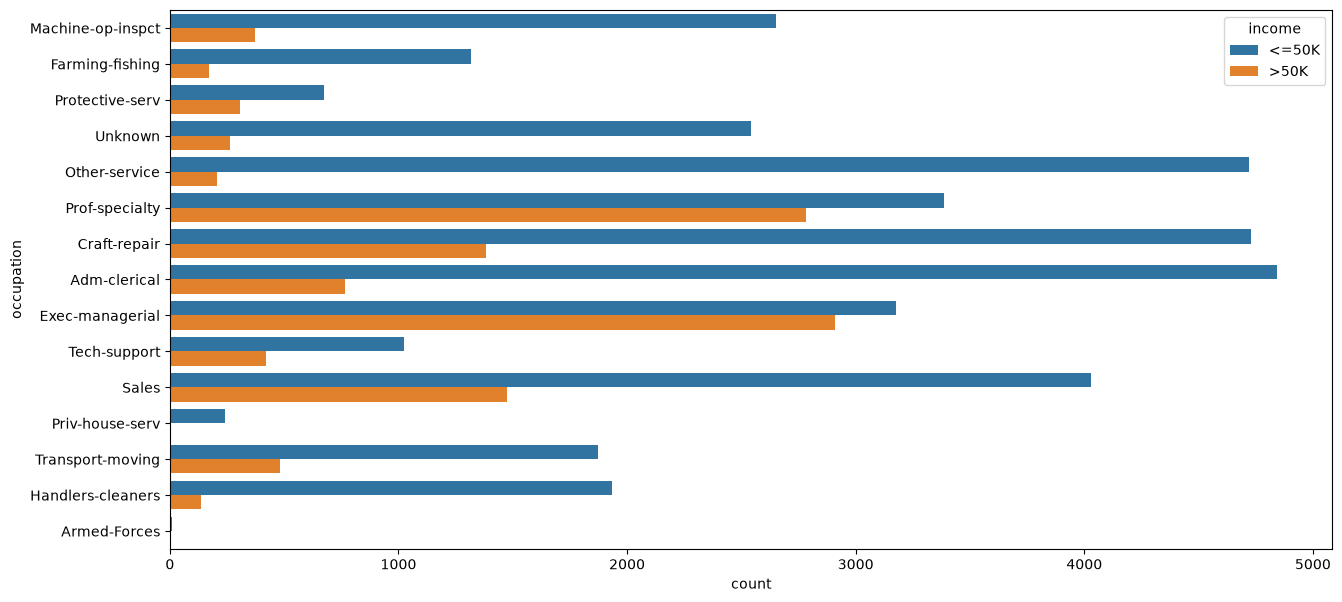

In [217]:
print(df["occupation"].value_counts())
t_df = df[["occupation"]]
t_df.loc[df["occupation"]=="?"] = "Unknown"
df["occupation"] = t_df["occupation"]
plt.figure(figsize=(15,7))
sns.countplot(data=df,y="occupation",orient="v",hue="income")

relationship
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64


<Axes: xlabel='relationship', ylabel='count'>

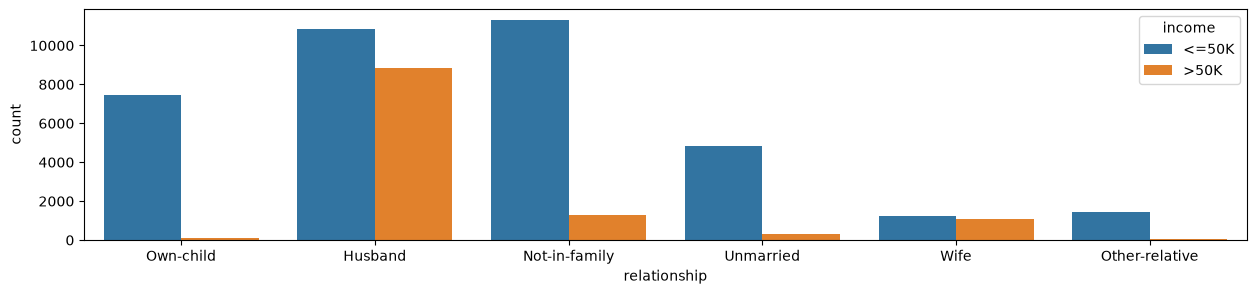

In [219]:
print(df["relationship"].value_counts())
plt.figure(figsize=(15,3))
sns.countplot(data=df,x="relationship",orient="h",hue="income")

## 4. Demographic Feature Analysis

This section explores the distributions of race, gender, and
native country.

The count plots show the representation of each category and
its observed distribution across income classes.

race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64


<Axes: xlabel='race', ylabel='count'>

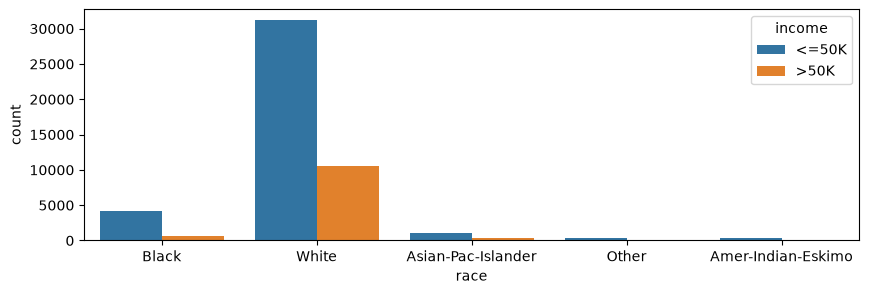

In [221]:
print(df["race"].value_counts())
plt.figure(figsize=(10,3))
sns.countplot(data=df,x="race",orient="h",hue="income")

gender
Male      32650
Female    16192
Name: count, dtype: int64


<Axes: xlabel='gender', ylabel='count'>

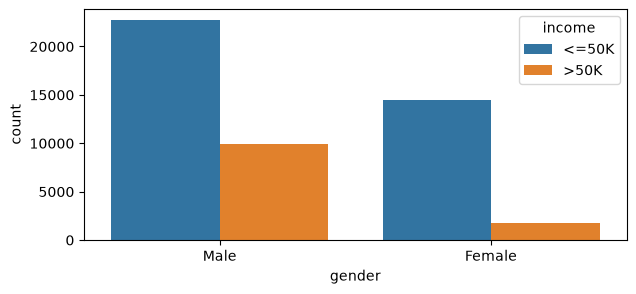

In [223]:
print(df["gender"].value_counts())
plt.figure(figsize=(7,3))
sns.countplot(data=df,x="gender",orient="h",hue="income")

native-country
United-States                 43832
Mexico                          951
?                               857
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Nicaragua                        49
Greece                           49
Peru         

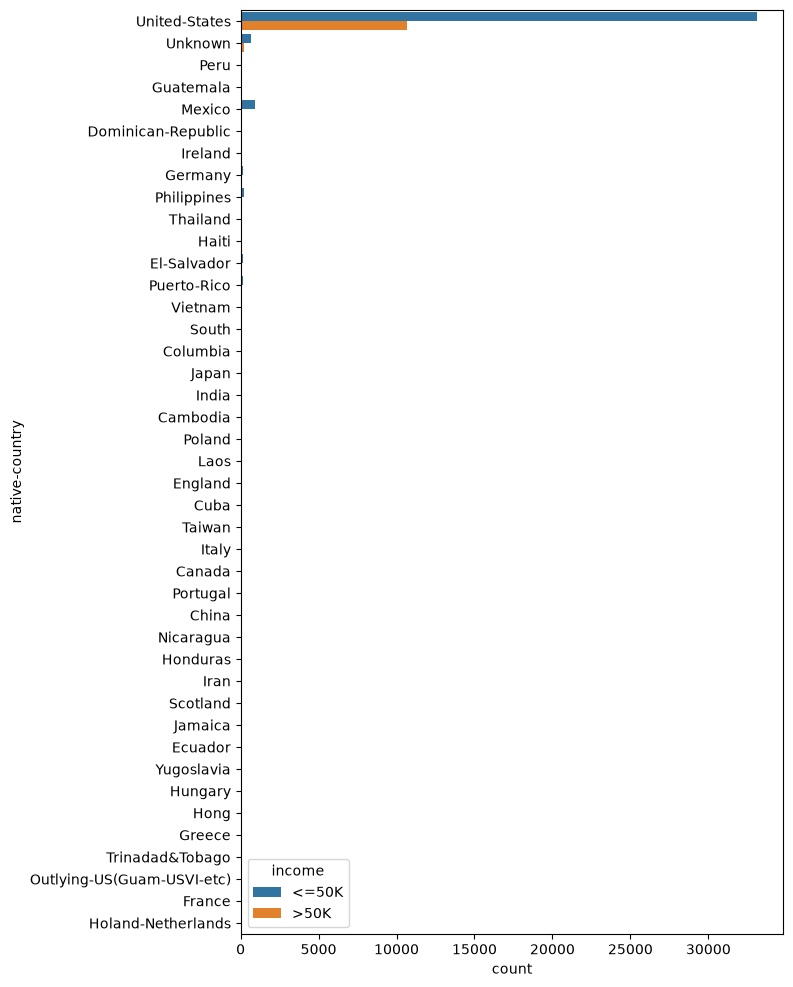

In [225]:
print(df["native-country"].value_counts())
t_df = df[["native-country"]]
t_df.loc[df["native-country"]=="?"] = "Unknown"
df["native-country"] = t_df["native-country"]
plt.figure(figsize=(7,12))
sns.countplot(data=df,y="native-country",orient="v",hue="income")
print("\n\nTotal Nations:", df["native-country"].nunique())

## 5. Numerical Feature Analysis

This section examines the distributions of age, capital gain,
capital loss, and hours worked per week.

The analysis focuses on central tendency, spread, skewness,
potential outliers, and differences in the distributions
between income classes.

These observations help determine whether scaling or additional
preprocessing may be appropriate before model training.

In [227]:
numerical_cols = [
    "age",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


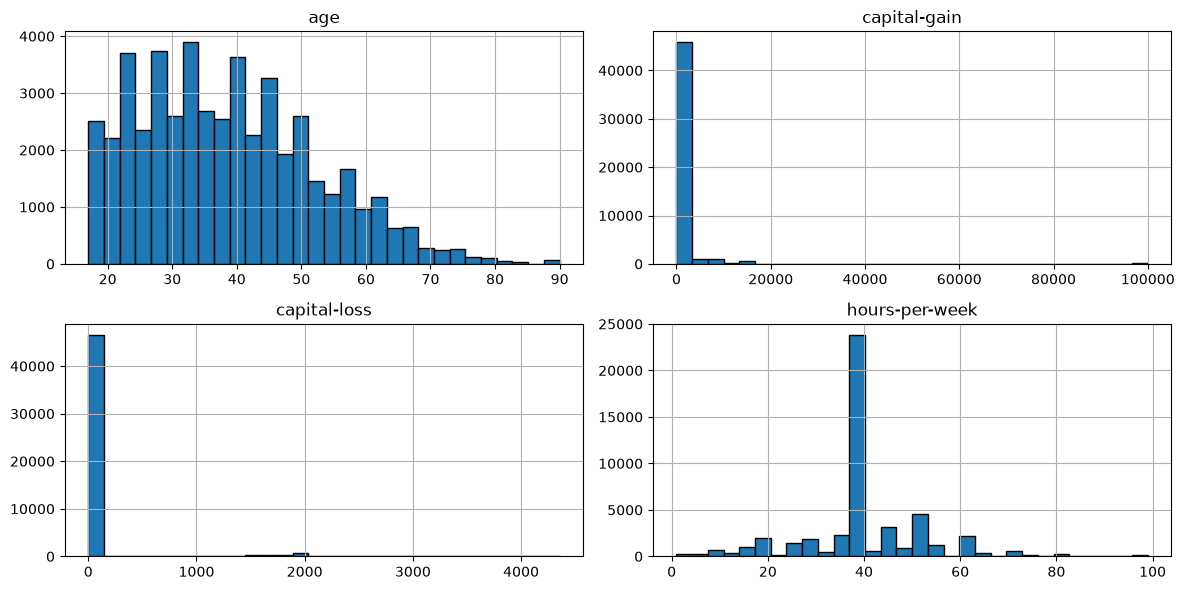

In [228]:
df[numerical_cols].hist(
    figsize=(12, 6),
    bins=30,
    edgecolor="black",
)

plt.tight_layout()
plt.show()

<Axes: xlabel='income', ylabel='age'>

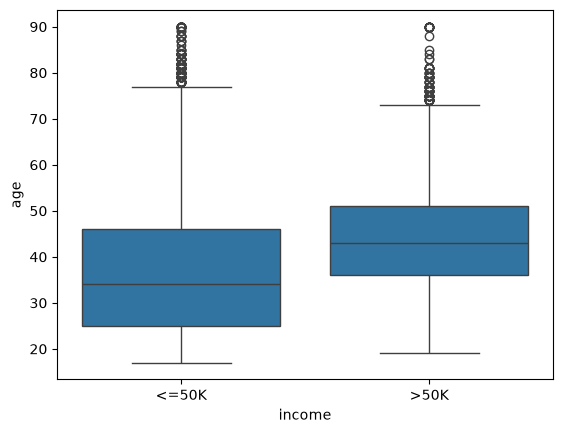

In [229]:
sns.boxplot(data=df,y="age",x="income")

## 6. Target Variable Analysis

The target variable is income, which is converted into a binary
label for classification.

The class distribution is examined to determine whether the
dataset is balanced or imbalanced.

Class imbalance is important because it can affect model
training and the interpretation of evaluation metrics.

The F1 score is used during model selection to account for
the balance between precision and recall.

In [230]:
income_counts = df["income"].value_counts()

income_percentages = (
    df["income"].value_counts(normalize=True) * 100
)

print("Income counts:")
print(income_counts)

print("\nIncome percentages:")
print(income_percentages.round(2))

Income counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Income percentages:
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


<Axes: xlabel='income', ylabel='count'>

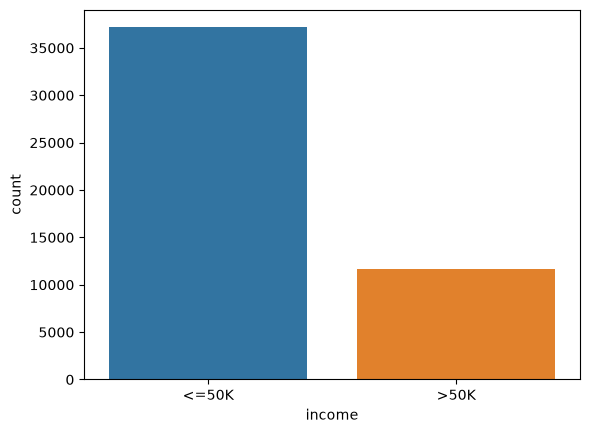

In [231]:
sns.countplot(data=df,x="income",hue="income")

In [232]:
def plot_income_rate(data, feature):
    income_rate = (
        data.assign(
            high_income=(data["income"] == ">50K").astype(int)
        )
        .groupby(feature, observed=False)["high_income"]
        .mean()
        .sort_values(ascending=False)
    )

    income_rate.plot(
        kind="bar",
        figsize=(12, 5),
        ylabel="Proportion with income >50K",
        title=f"High-income proportion by {feature}"
    )

    plt.tight_layout()
    plt.show()

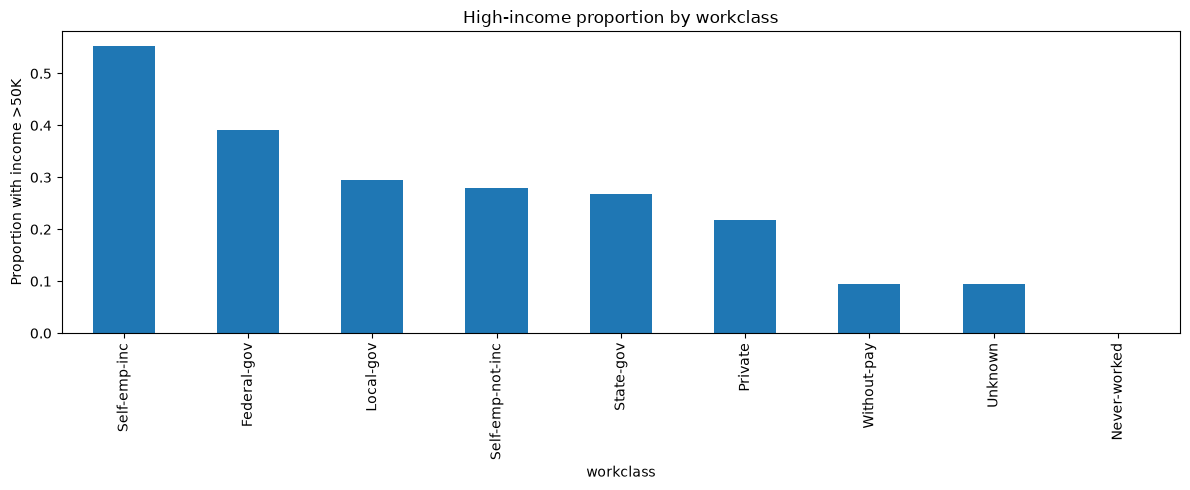

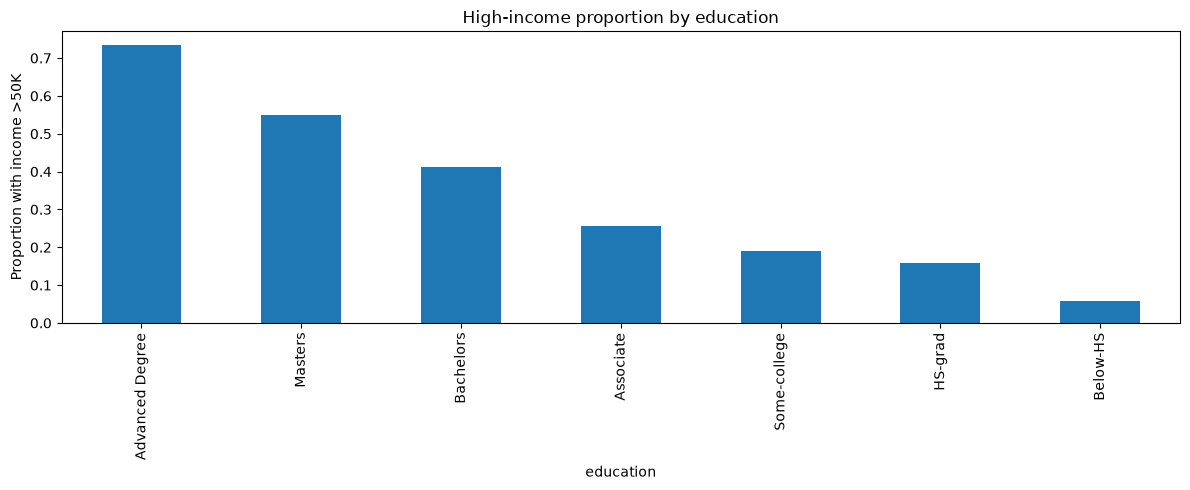

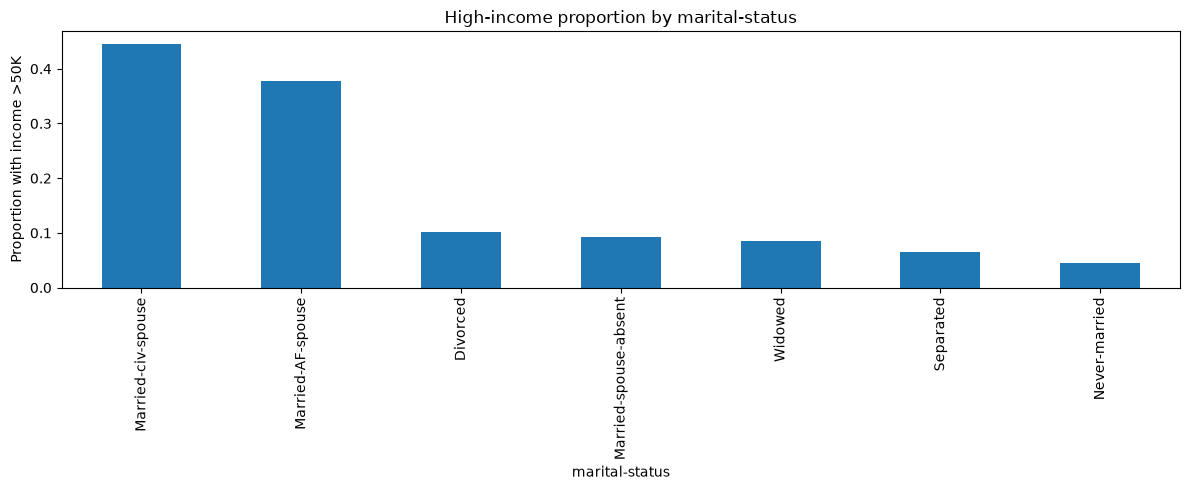

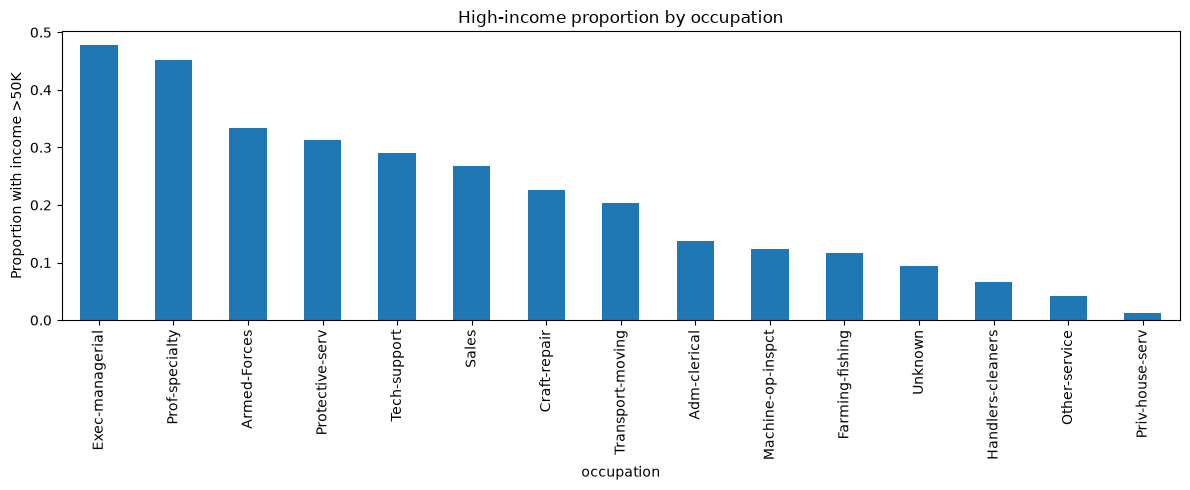

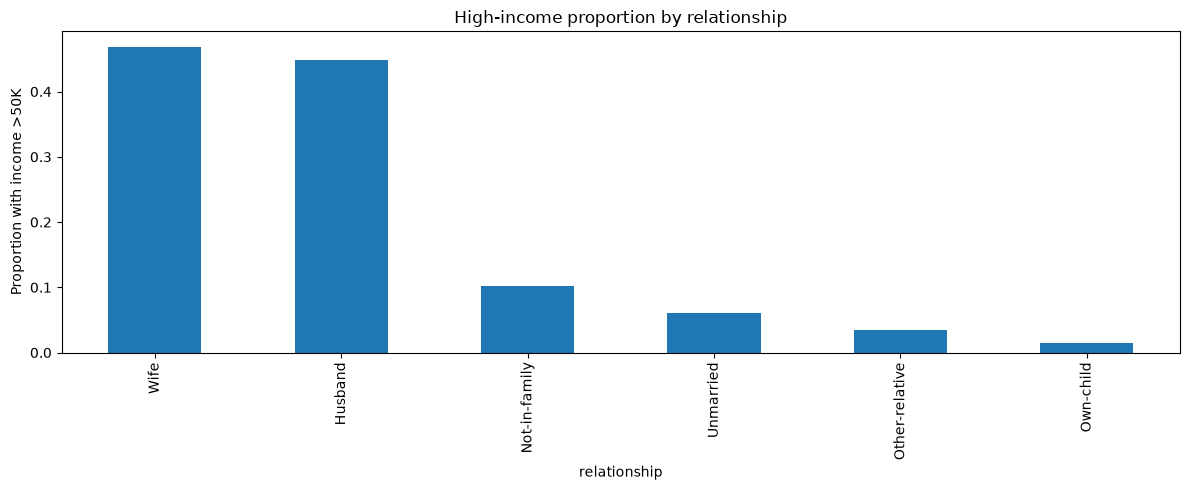

In [233]:
plot_income_rate(df, "workclass")
plot_income_rate(df, "education")
plot_income_rate(df, "marital-status")
plot_income_rate(df, "occupation")
plot_income_rate(df, "relationship")

## 7. EDA Summary and Preprocessing Decisions

The EDA identifies the following considerations for preprocessing:

- Categorical features contain missing values represented by `?`.
- Several categorical variables have uneven category frequencies.
- Education is grouped into ordered attainment levels for ordinal encoding.
- Categorical features are encoded using binary and one-hot encoding.
- Numerical features are standardized before model training.
- The target variable is converted into a binary classification label.

The preprocessing pipeline should preserve the separation between
training and testing data to prevent information leakage.

The final dataset is then divided into training and testing subsets
for model development and evaluation.

In [209]:
workclass_encoder = ce.BinaryEncoder()
binary_encoded = workclass_encoder.fit_transform(df["workclass"])
df = pd.concat([df, binary_encoded], axis=1)

In [214]:
OrdEnc = OrdinalEncoder(categories=[["Below-HS","HS-grad","Some-college","Associate","Bachelors","Masters","Advanced Degree"]])
df["Edu-Encoded"] = OrdEnc.fit_transform(df[["education"]])
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,workclass_0,workclass_1,workclass_2,workclass_3,Edu-Encoded
0,25,Private,226802,Below-HS,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0,0,0,1,0.0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0,0,0,1,1.0
2,28,Local-gov,336951,Associate,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,0,0,1,0,3.0
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,0,0,0,1,2.0
4,18,Unknown,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,0,0,1,1,2.0


In [218]:
occupation_encoder = ce.BinaryEncoder()
binary_encoded = occupation_encoder.fit_transform(df["occupation"])
df = pd.concat([df, binary_encoded], axis=1)

In [216]:
marital_encoder = ce.BinaryEncoder()
binary_encoded = marital_encoder.fit_transform(df["marital-status"])
df = pd.concat([df, binary_encoded], axis=1)

In [220]:
relationship_encoder = ce.BinaryEncoder()
binary_encoded = relationship_encoder.fit_transform(df["relationship"])
df = pd.concat([df, binary_encoded], axis=1)

In [226]:
country_encoder = ce.BinaryEncoder()
binary_encoded = country_encoder.fit_transform(df["native-country"])
df = pd.concat([df, binary_encoded], axis=1)

In [222]:
df = df.join(pd.get_dummies(df["race"],dtype='int32',prefix='race'))
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,...,occupation_2,occupation_3,relationship_0,relationship_1,relationship_2,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,25,Private,226802,Below-HS,7,Never-married,Machine-op-inspct,Own-child,Black,Male,...,0,1,0,0,1,0,0,1,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,...,1,0,0,1,0,0,0,0,0,1
2,28,Local-gov,336951,Associate,12,Married-civ-spouse,Protective-serv,Husband,White,Male,...,1,1,0,1,0,0,0,0,0,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,...,0,1,0,1,0,0,0,1,0,0
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,...,0,0,0,0,1,0,0,0,0,1


In [224]:
df = df.join(pd.get_dummies(df["gender"],dtype='int32',prefix='gender'))
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,...,relationship_0,relationship_1,relationship_2,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,gender_Female,gender_Male
0,25,Private,226802,Below-HS,7,Never-married,Machine-op-inspct,Own-child,Black,Male,...,0,0,1,0,0,1,0,0,0,1
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,...,0,1,0,0,0,0,0,1,0,1
2,28,Local-gov,336951,Associate,12,Married-civ-spouse,Protective-serv,Husband,White,Male,...,0,1,0,0,0,0,0,1,0,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,...,0,1,0,0,0,1,0,0,0,1
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,...,0,0,1,0,0,0,0,1,1,0


In [234]:
targ = pd.get_dummies(df["income"],dtype='int32')
targ = targ.drop(columns='<=50K')
df["Inc_over50"] = targ
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,...,race_White,gender_Female,gender_Male,native-country_0,native-country_1,native-country_2,native-country_3,native-country_4,native-country_5,Inc_over50
0,25,Private,226802,Below-HS,7,Never-married,Machine-op-inspct,Own-child,Black,Male,...,0,0,1,0,0,0,0,0,1,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,...,1,0,1,0,0,0,0,0,1,0
2,28,Local-gov,336951,Associate,12,Married-civ-spouse,Protective-serv,Husband,White,Male,...,1,0,1,0,0,0,0,0,1,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,...,0,0,1,0,0,0,0,0,1,1
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,...,1,1,0,0,0,0,0,0,1,0


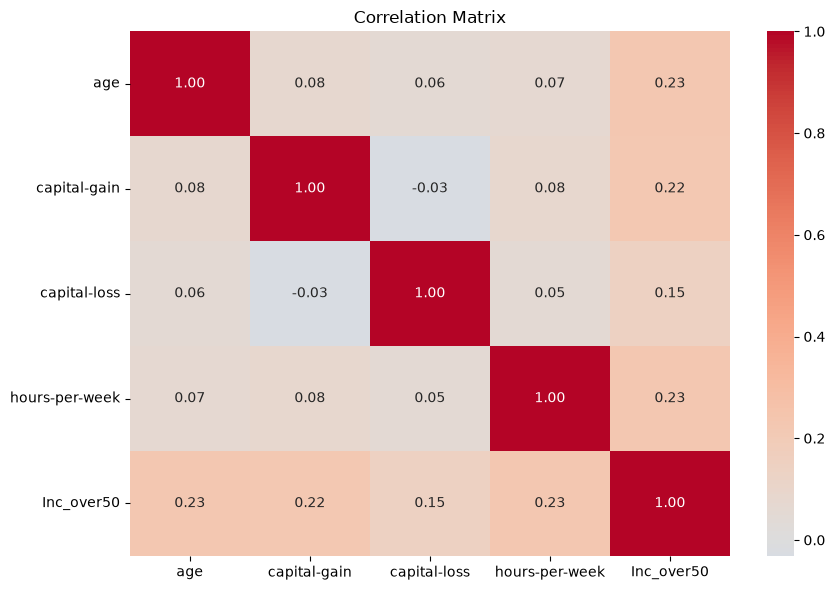

In [235]:
corr_cols = [
    "age",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "Inc_over50"
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [144]:
df = df.drop(columns=["fnlwgt","education","educational-num","marital-status", "occupation","relationship","race","gender","native-country","workclass","income"])
df=df.dropna()
df.drop_duplicates(inplace=True)
df.head()

,age,capital-gain,capital-loss,hours-per-week,workclass_0,workclass_1,workclass_2,workclass_3,Edu-Encoded,marital-status_0,...,race_White,gender_Female,gender_Male,native-country_0,native-country_1,native-country_2,native-country_3,native-country_4,native-country_5,Inc_over50
0,25,0,0,40,0,0,0,1,0.0,0,...,0,0,1,0,0,0,0,0,1,0
1,38,0,0,50,0,0,0,1,1.0,0,...,1,0,1,0,0,0,0,0,1,0
2,28,0,0,40,0,0,1,0,3.0,0,...,1,0,1,0,0,0,0,0,1,1
3,44,7688,0,40,0,0,0,1,2.0,0,...,0,0,1,0,0,0,0,0,1,1
4,18,0,0,30,0,0,1,1,2.0,0,...,1,1,0,0,0,0,0,0,1,0


In [145]:
x = df.drop(columns="Inc_over50")
y = df["Inc_over50"]

In [146]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [147]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(x_train)
test_scaled = scaler.transform(x_test)

In [148]:
models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "C":[0.01,0.1,1,10],
        }
    ),
    "RandomForestClassifier" : (
        RandomForestClassifier(random_state=42,n_jobs=-1),
        {
            "n_estimators":[100,200],
            "max_depth" : [None, 10, 20],
            "min_samples_split": [2,5]
        }
    ),
    "KNeighborsClassifier" : (
        KNeighborsClassifier(),
        {
            "n_neighbors" : [3,5,7,9],
            "weights": ["uniform","distance"],
            "p" : [1,2]
        }
    ),
    "Naive Bayes" : (
        GaussianNB(),
        {
            "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    ),
    "Gradient Boosting" : (
        GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.001, 0.01, 0.1, 0.2],
            "max_depth": [2,3,5]

        }
    )
}

In [149]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [150]:
best_models = {}
results = []

In [151]:
for name, (model, param_grid) in models.items():
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    grid_search.fit(train_scaled, y_train)
    best_models[name] = grid_search.best_estimator_

    results.append({
        "Model": name,
        "Best Parameters": grid_search.best_params_,
        "Best CV F1": grid_search.best_score_
    })

In [152]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [153]:
X_train = np.asarray(train_scaled, dtype=np.float32)
X_test = np.asarray(test_scaled, dtype=np.float32)

y_train = np.asarray(y_train, dtype=np.float32)
y_test = np.asarray(y_test, dtype=np.float32)

n_features = X_train.shape[1]

In [154]:
train_dataset = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(y_train)
)

test_dataset = TensorDataset(
    torch.tensor(X_test),
    torch.tensor(y_test)
)

In [155]:
class CNN1D(nn.Module):
    def __init__(self, n_features, n_conv_layers, channels, kernel_size, dropout):
        super().__init__()
        layers = []
        in_ch = 1
        for i in range(n_conv_layers):
            out_ch = channels * (2 ** i)
            layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.MaxPool1d(2)
            ]
            in_ch = out_ch
        self.conv = nn.Sequential(*layers)

        with torch.no_grad():
            flat_dim = self.conv(torch.zeros(1, 1, n_features)).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(flat_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.fc(self.conv(x)).squeeze(1)

In [156]:
class TorchClassifierWrapper:
    """Gives the torch model a sklearn-style .predict for the confusion-matrix cell."""
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def predict(self, X):
        self.model.eval()
        X_t = torch.tensor(np.asarray(X, dtype=np.float32)).unsqueeze(1).to(self.device)
        with torch.no_grad():
            probs = torch.sigmoid(self.model(X_t)).cpu().numpy()
        return (probs > 0.5).astype(int)

In [157]:
def objective(trial):
    n_conv_layers = trial.suggest_int("n_conv_layers", 1, 3)
    channels = trial.suggest_categorical("channels", [8, 16, 32])
    kernel_size = trial.suggest_categorical("kernel_size", [3, 5])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr).unsqueeze(1), torch.tensor(y_tr)),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val).unsqueeze(1), torch.tensor(y_val)),
        batch_size=batch_size, shuffle=False
    )

    model = CNN1D(n_features, n_conv_layers, channels, kernel_size, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(15):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            probs = torch.sigmoid(model(xb.to(device))).cpu().numpy()
            preds.extend((probs > 0.5).astype(int))
            targets.extend(yb.numpy())

    return f1_score(targets, preds, zero_division=0)

In [158]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-09-25 22:55:31,366] A new study created in memory with name: no-name-99565849-18a6-4b69-b3a7-256748d5781a


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-25 22:55:50,422] Trial 0 finished with value: 0.6454046639231824 and parameters: {'n_conv_layers': 2, 'channels': 16, 'kernel_size': 3, 'dropout': 0.28846326843473824, 'lr': 0.008659359784505128, 'batch_size': 32, 'weight_decay': 7.472197985669035e-06}. Best is trial 0 with value: 0.6454046639231824.
[I 2026-09-25 22:56:05,814] Trial 1 finished with value: 0.6468401486988847 and parameters: {'n_conv_layers': 1, 'channels': 32, 'kernel_size': 3, 'dropout': 0.32386600312688796, 'lr': 0.003997869231077847, 'batch_size': 32, 'weight_decay': 0.00017230473906809914}. Best is trial 1 with value: 0.6468401486988847.
[I 2026-09-25 22:56:11,176] Trial 2 finished with value: 0.667098445595855 and parameters: {'n_conv_layers': 2, 'channels': 8, 'kernel_size': 5, 'dropout': 0.19919991678023724, 'lr': 0.002792554394969957, 'batch_size': 128, 'weight_decay': 4.808414808312527e-05}. Best is trial 2 with value: 0.667098445595855.
[I 2026-09-25 22:56:30,480] Trial 3 finished with value: 0.659

In [159]:
best_params = study.best_params

In [160]:
final_train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train).unsqueeze(1), torch.tensor(y_train)),
    batch_size=best_params["batch_size"], shuffle=True
)

In [161]:
cnn_model = CNN1D(
    n_features,
    best_params["n_conv_layers"],
    best_params["channels"],
    best_params["kernel_size"],
    best_params["dropout"]
).to(device)

In [162]:
optimizer = torch.optim.Adam(
    cnn_model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"]
)
criterion = nn.BCEWithLogitsLoss()

In [163]:
for epoch in range(30):
    cnn_model.train()
    for xb, yb in final_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn_model(xb), yb)
        loss.backward()
        optimizer.step()


In [164]:
best_models["CNN (PyTorch)"] = TorchClassifierWrapper(cnn_model, device)

In [165]:
results.append({
    "Model": "CNN (PyTorch)",
    "Best Parameters": best_params,
    "Best CV F1": study.best_value
})

In [166]:
tuning_results = pd.DataFrame(results)
tuning_results

,Model,Best Parameters,Best CV F1
0,LogisticRegression,{'C': 10},0.638635
1,RandomForestClassifier,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",0.683334
2,KNeighborsClassifier,"{'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}",0.612488
3,Naive Bayes,{'var_smoothing': 1e-09},0.615539
4,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 5, 'n_esti...",0.713977
5,CNN (PyTorch),"{'n_conv_layers': 3, 'channels': 32, 'kernel_s...",0.683234


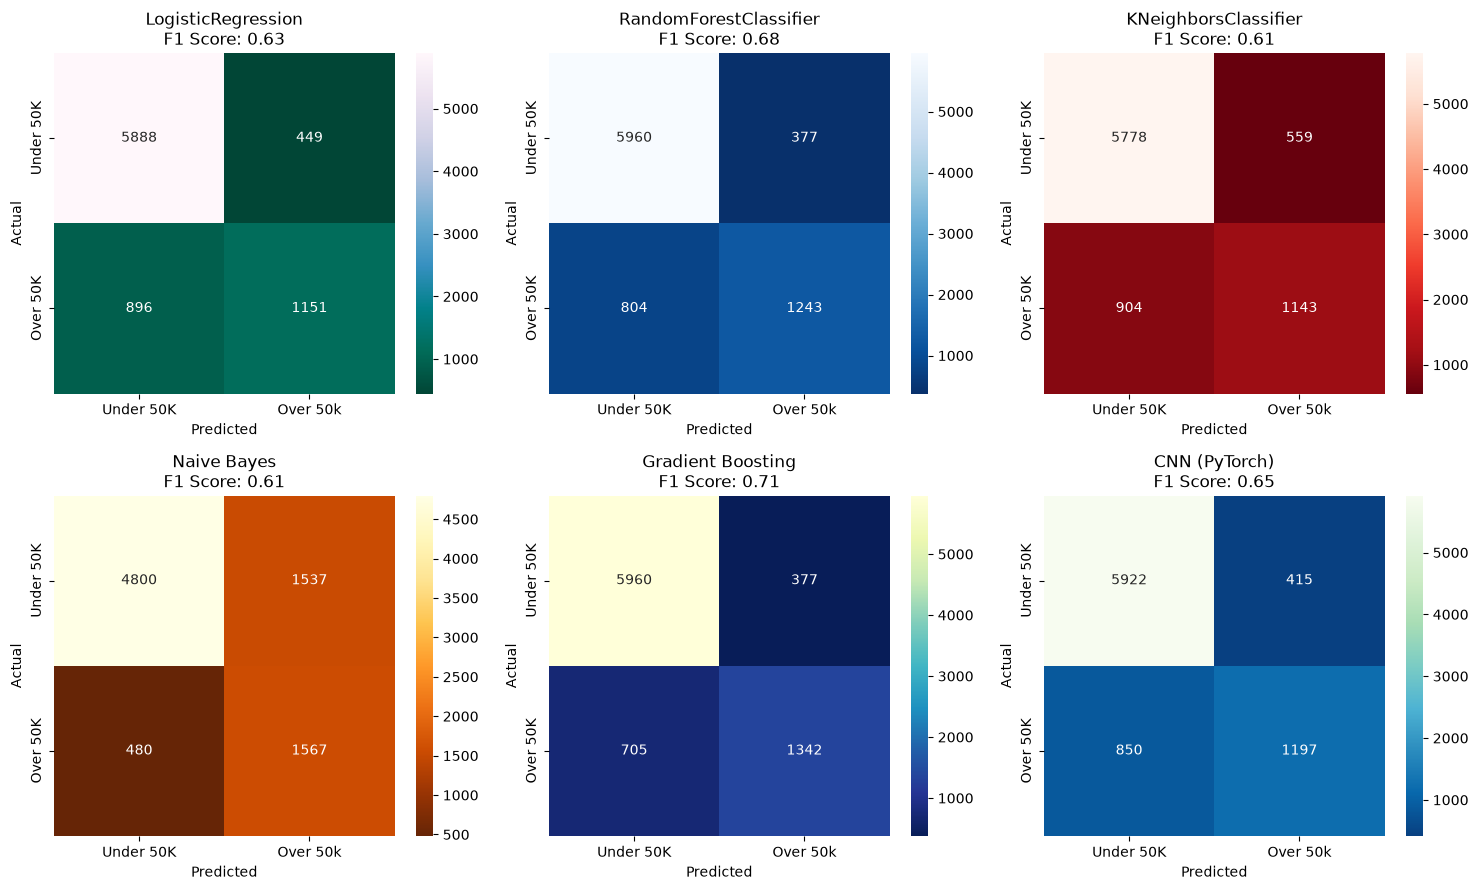

In [176]:
n_models = len(best_models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
cmap = ["PuBuGn_r","Blues_r","Reds_r","YlOrBr_r","YlGnBu_r","GnBu_r"]
i=0

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(test_scaled)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    f1 = f1_score(y_test, y_pred, zero_division=0)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Under 50K", "Over 50k"],
        yticklabels=["Under 50K", "Over 50K"],
        ax=ax,
        cmap=cmap[i]
    )

    i+=1

    ax.set_title(f"{name}\nF1 Score: {f1:.2f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Hide unused subplot
for ax in axes[n_models:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [168]:
os.makedirs("models", exist_ok=True)
os.makedirs("scalers", exist_ok=True)
os.makedirs("encoders", exist_ok=True)

encoders = {
    "workclass": workclass_encoder,
    "marital_status": marital_encoder,
    "occupation": occupation_encoder,
    "relationship": relationship_encoder,
    "native_country": country_encoder,
    "education_ordinal": OrdEnc,
}

In [169]:
joblib.dump(best_models["Gradient Boosting"], "models/gradient_boosting_model.joblib")
joblib.dump(scaler, "scalers/scaler.joblib")

joblib.dump(encoders, "encoders/encoders.joblib")
joblib.dump(list(x.columns), "encoders/feature_order.joblib")

['encoders/feature_order.joblib']